In [8]:
import pandas as pd


In [16]:
df = pd.read_csv('/home/wenyuantong/Desktop/data/Albatross_minmax_norm_arabi.csv')

In [10]:
display(df.head())

,asphericity,scaling_exponent,Normalized Rg (A),Normalized Re (A)
IDR ID,,,,
tr|A0A1P8B415|A0A1P8B415_ARATH Triglyceride lipase OS=Arabidopsis thaliana OX=3702 GN=HIL1 PE=1 SV=1_1_66,0.404,0.535,0.042808,0.051648
tr|A0A1P8B415|A0A1P8B415_ARATH Triglyceride lipase OS=Arabidopsis thaliana OX=3702 GN=HIL1 PE=1 SV=1_306_525,0.419,0.569,0.144631,0.169385
sp|A4FVP2|TPS03_ARATH Terpenoid synthase 3; chloroplastic OS=Arabidopsis thaliana OX=3702 GN=TPS03 PE=1 SV=1_1_34,0.455,0.568,0.012291,0.022863
sp|F4I316|SUN3_ARATH SUN domain-containing protein 3 OS=Arabidopsis thaliana OX=3702 GN=SUN3 PE=1 SV=1_1_292,0.427,0.552,0.172118,0.182981
sp|F4I316|SUN3_ARATH SUN domain-containing protein 3 OS=Arabidopsis thaliana OX=3702 GN=SUN3 PE=1 SV=1_415_496,0.438,0.561,0.061624,0.074373


In [6]:
df.set_index(df.columns[0], inplace=True)

In [12]:
import scanpy as sc

In [15]:
adata = sc.AnnData(df)
print(adata)

AnnData object with n_obs × n_vars = 23616 × 4


In [17]:
sc.tl.pca(adata, svd_solver='arpack')

In [18]:
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

In [25]:
sc.tl.leiden(adata, resolution=0.5)

/tmp/ipykernel_330544/1771924308.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


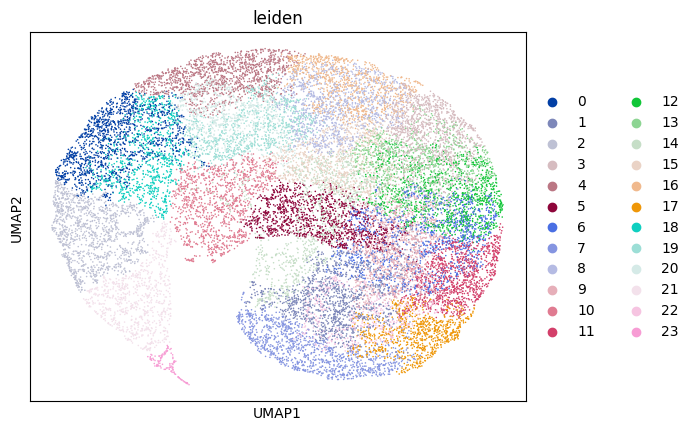

In [26]:
sc.tl.umap(adata)
sc.pl.umap(adata, color='leiden')

# You can also access the cluster assignments:
# print(adata.obs['leiden'].head())

In [27]:
print(adata.obs['leiden'].head())

IDR ID
tr|A0A1P8B415|A0A1P8B415_ARATH Triglyceride lipase OS=Arabidopsis thaliana OX=3702 GN=HIL1 PE=1 SV=1_1_66            12
tr|A0A1P8B415|A0A1P8B415_ARATH Triglyceride lipase OS=Arabidopsis thaliana OX=3702 GN=HIL1 PE=1 SV=1_306_525          0
sp|A4FVP2|TPS03_ARATH Terpenoid synthase 3; chloroplastic OS=Arabidopsis thaliana OX=3702 GN=TPS03 PE=1 SV=1_1_34    17
sp|F4I316|SUN3_ARATH SUN domain-containing protein 3 OS=Arabidopsis thaliana OX=3702 GN=SUN3 PE=1 SV=1_1_292          2
sp|F4I316|SUN3_ARATH SUN domain-containing protein 3 OS=Arabidopsis thaliana OX=3702 GN=SUN3 PE=1 SV=1_415_496        8
Name: leiden, dtype: category
Categories (24, object): ['0', '1', '2', '3', ..., '20', '21', '22', '23']


In [30]:
sc.tl.leiden(adata, resolution=0.25)

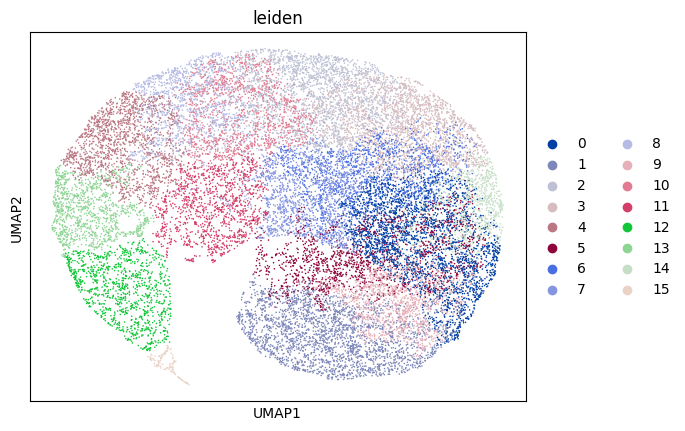

In [31]:
sc.tl.umap(adata)
sc.pl.umap(adata, color='leiden')

# You can also access the cluster assignments:
# print(adata.obs['leiden'].head())

In [35]:
# Assuming you have an AnnData object named 'adata' and have performed necessary preprocessing
# For example, scaling is often done before PCA:
# sc.pp.scale(adata, max_value=10)

# Run PCA
# n_comps: number of principal components to compute
# svd_solver: solver to use for the singular value decomposition ('arpack' is a common choice)
# use_highly_variable: set to True if you want to run PCA only on highly variable genes (recommended)
sc.tl.pca(adata, n_comps=3, svd_solver='arpack')

print("PCA computation complete. Results stored in adata.obsm['X_pca']")
# You can access the PCA coordinates like this:
# pca_coordinates = adata.obsm['X_pca']
# print(pca_coordinates)

# You can also access the variance ratio explained by each component:
# print(adata.uns['pca']['variance_ratio'])

PCA computation complete. Results stored in adata.obsm['X_pca']


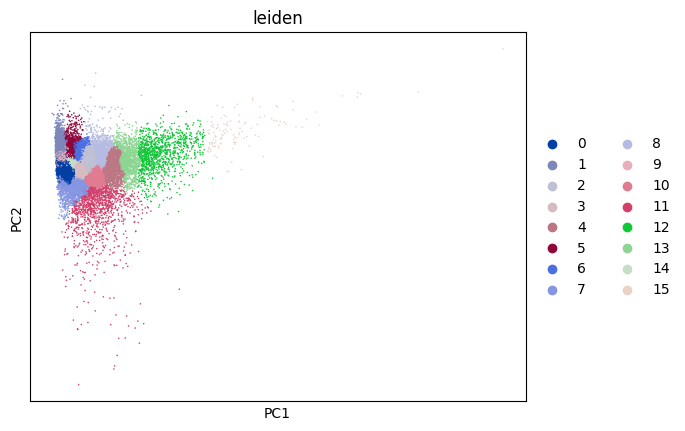

In [37]:
sc.pl.pca(adata, components="1,2", color='leiden')

In [29]:
#repeat clustering using normalized data

adata_norm = sc.AnnData(df)
print(adata_norm)

# You typically need to perform some preprocessing steps before clustering,
# such as normalization, scaling, and dimensionality reduction (e.g., PCA).
# For example:
sc.pp.normalize_total(adata_norm)
sc.pp.log1p(adata_norm)
sc.pp.highly_variable_genes(adata_norm, n_top_genes=2000)
sc.pp.scale(adata_norm, max_value=10)
sc.tl.pca(adata_norm, svd_solver='arpack')

# 1. Compute the neighborhood graph
# This step builds a graph of cells based on their similarity in a reduced dimension space (like PCA).
# n_neighbors: number of neighbors to consider for each cell
# use_rep: the representation to use (e.g., 'X_pca' if you ran PCA)

#sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# 2. Perform Leiden clustering
# This applies the Leiden algorithm to the constructed graph.
# resolution: higher values lead to more clusters

#sc.tl.leiden(adata, resolution=0.5)

# The clustering results are stored in adata.obs['leiden'].

# You can visualize the clustering results, for example, using a UMAP plot:
# sc.tl.umap(adata)
# sc.pl.umap(adata, color='leiden')

# You can also access the cluster assignments:
# print(adata.obs['leiden'].head())

AnnData object with n_obs × n_vars = 23616 × 5


/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: X converted to numpy array with dtype object
  return fn(*args_all, **kw)
/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


TypeError: can only concatenate str (not "float") to str

In [22]:
%pip3 install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 38.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [igraph]━━━━ 1/2 [igraph]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /home/wenyuantong/.local/share/pipx/venvs/jupyterlab/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
%pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.0 MB/s  0:00:00

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /home/wenyuantong/.local/share/pipx/venvs/jupyterlab/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


NameError: name 'merged_df' is not defined